**<h1> Notebook Appendix**

The below notebook in divided in to following parts:

A) Introduction: Monte Carlo Scheme/ Method
<BR>
B) Valuing the Options using different Monte Carlo Schemes (including the antithetic caluLaltions)
<br>
C) BSM Option Valuation (will act as a benchmark)
<br>
D) Results, Comparison, Error TableS for Option values under different schemes/ methods
<br>
E) Observations
<br>
F) Conclusion
<br>
G) References

**<h1> A) Introduction: Monte Carlo Scheme/ Method**

Monte Carlo methods are any process that consumes random numbers. These are part of computational algorithms which are based on random sampling to obtain numerical results. Monte Carlo methods are proved to be a very valuable and flexible computational tool in finance and is one of the most widely used methods for optimization and numerical integration problems.

These methods are widely used in high dimensional problems; pricing exotics and complex derivatives where closed form solutions are not directly available. Monte Carlo methods are not just adapted in pricing complex derivatives, It is also extensively used in estimating the portfolio risk such as Value-at-Risk and Expected Shortfall and used in the calculation of worst-case scenarios in stress testing. The downside to that is, it is very computational intensive and demanding.

<br>

**Monte Carlo Simulation**

A method of estimating the value of an unknown quantity using the principles of inferential statistics.

We take the population and then we sample it by drawing a proper subset. And then we make an inference about the population based upon some set of statistics we do on the sample.

And, the key fact that makes them work, that if we choose the sample at random, the sample will tend to exhibit the same properties as the population from which it is drawn.

<br>

The Monte Carlo pricing procedure follows these five steps:

1. Simulate the risk-neutral random walk starting at today's value of the
asset $S0$ over the required time horizon $T$. This gives one realization
of the underlying price path.

2. For this realization, calculate the option payoff.

3. Perform many more such realizations over the time horizon.

4. Calculate the average payoff over all realizations

5. Take the present value of this average — this is the option value

<br>

The underlying stock is assumed to follows Geometric Brownian Motion (GBM), which is giverned by the following Stochastic differential equation (SDE):

$$dS = rS\,dt + \sigma S\,dW_t$$

<br>

This report implements and compares **three schemes** for
simulating the stock price:
<br>

**1. Euler-Maruyama Scheme** — in this scheme we discretize the SDE, breaking the time horizons into **n_steps**:
$$S_{i+1} = S_i \left(1 + r\,\delta t + \sigma\,\phi\sqrt{\delta t}\right)$$

**2. Closed Form Solution** — this scheme is the exact simulation of GBM without discretization error:
$$S_T = S_0 \exp\left(\left(r - \frac{1}{2}\sigma^2\right)T + \sigma\phi\sqrt{T}\right)$$

**3. Milstein Scheme** — this scheme improves accuracy by adding a second-order correction term in the Euler-Maruyama:
$$S_{i+1} = S_i \left(1 + r\,\delta t + \sigma\,\phi\sqrt{\delta t} +
\frac{1}{2}\sigma^2\left(\phi^2 - 1\right)\delta t\right)$$

where $\phi \sim \mathcal{N}(0,1)$ in all three cases.

<br>

The theoretical foundation rests on the **risk-neutral pricing framework**, where the
option value is given by the discounted expected payoff at time T  under the risk-neutral measure Q:

$$V(S, t) = e^{-r(T-t)} \mathbb{E}^{\mathbb{Q}}[\textbf{Payoff}]$$

<br><br>

**Valuation of Eurpoean Call Option:**

First Calculate Averge of Payoff at Maturity of Option:
$$\text{Average Payoff} = \frac{1}{n} \sum_{i=1}^{n} \max\left(S_T^{(i)} - E,\ 0\right)$$

Finally Calculate the present value of the Average Payoff:
$$\text{Option Price} = PV\ \text{of Average} = e^{-r(T-t)} \times \frac{1}{n} \sum_{i=1}^{n} \max\left(S_T^{(i)} - E,\ 0\right)$$

<br>

**Valuation of Binary Call Option:**

Binary call is the discounted probability that the stock finishes above the strike at maturity under risk neutral measure i.e. N(d2)

First Calculate Averge of Payoff at Maturity of Option
$$\text{Average} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\left(S_T^{(i)} > E\right) \quad i = 1, \ldots, n$$

Finally Calculate the present value of the Average Payoff
$$\text{Option Price} = PV \ \text{of Average} = e^{-r(T-t)} \times \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}\left(S_T^{(i)} > E\right)$$

**Importing relevant Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

**Inputs used to value option**:

**S0 = 100** (Today's Stock Price) <br> <br>
**E or K = 100** (Strike) <br> <br>
**T-t = 1** (Time to expiry in years) <br> <br>
**sigma = 20%** (Volatility) <br> <br>
**r = 5%** (Risk free Interest Rate)

**<h1> B) Valuing the Options using different Monte Carlo Schemes (including the antithetic calcualtions)**

**<h2> B1) Valuations using Euler-Maruyama method**

**Simulating Geometric Brownian Motion Paths (Euler-Maruyama method)**

$$S_{i+1} = S_i \left(1 + r\,\delta t + \sigma\,\phi\sqrt{\delta t}\right)$$


In [2]:
def simulate_gbm_paths (S0, r, sigma, T, n_paths, n_steps):
  dt = T/n_steps
  paths = np.zeros((n_paths, n_steps + 1))  # Creating a DataFrame with all zeros
  paths[:,0] = S0

  for t in range (1,n_steps + 1):
    z = np.random.standard_normal(n_paths)

    # Applying Euler Discretization of SDE

    paths[:,t] = paths[:,t-1] * (1 + r * dt + sigma * z * np.sqrt(dt))

    paths[:, t] = np.maximum(paths[:, t], 0) # this to avoid negative paths

  return paths

**Using the above defined function and Inputs as provided in Exam 2 question to create a DataFrame with simulated price path for the underlying S0**

In [3]:
paths = pd.DataFrame(simulate_gbm_paths(S0=100, r=0.05, sigma=0.2, T=1, n_paths=50000, n_steps=252))
paths

,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,101.760412,99.635681,99.345231,100.942444,102.113309,102.383623,102.783534,100.448422,99.067457,...,112.682014,114.215822,116.060833,117.573852,119.176056,121.394207,121.485044,121.377233,121.925220,122.774535
1,100.0,100.949868,100.613103,100.231852,100.613678,102.039417,103.833102,106.612490,106.301018,106.074307,...,106.255186,105.255467,104.746674,105.181740,106.869348,106.033382,106.460632,106.237983,104.241595,104.028391
2,100.0,101.088115,101.048635,100.123540,99.229173,100.146333,100.905954,99.773415,99.726542,98.626941,...,106.489345,107.158943,108.175585,107.785193,107.498685,109.179588,108.918460,107.864194,106.968947,108.192156
3,100.0,101.137671,102.789051,101.030280,102.447455,103.848553,102.800357,100.608449,101.728132,102.328674,...,97.198737,97.723706,95.694603,93.790884,94.086638,94.842950,93.127974,93.406257,94.245445,96.889682
4,100.0,96.803337,94.659578,94.291456,93.527009,93.748379,94.486305,91.889573,89.240614,88.550300,...,75.144950,76.392831,76.351953,76.495775,77.262164,75.712650,75.974781,74.916781,75.638350,75.302831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,100.0,99.968841,101.072979,101.205418,102.944726,103.619907,103.862867,104.578320,105.278654,104.113536,...,105.332241,104.739177,102.371799,103.268582,101.784908,99.654526,98.570685,98.479019,97.608087,98.153284
49996,100.0,101.155120,101.145621,99.319967,99.887389,102.054864,101.651447,102.609938,101.593144,102.299551,...,117.829348,119.797553,119.390087,120.089519,118.958941,117.469591,116.658323,115.656305,118.764455,121.642700
49997,100.0,101.061517,103.749223,105.759053,107.347045,108.234945,107.899250,106.019955,105.619698,106.413064,...,80.964928,78.708089,78.531590,77.282394,77.884192,77.794352,79.287044,79.858972,80.115339,79.556677
49998,100.0,100.871356,101.915200,102.046656,99.571048,100.944292,102.262574,101.285058,101.644224,100.634364,...,140.167021,141.411803,147.007555,146.981383,145.995293,148.400499,146.916374,149.100743,146.390817,145.171488


**Visualisation of Simulated Paths (Displaying 100)**

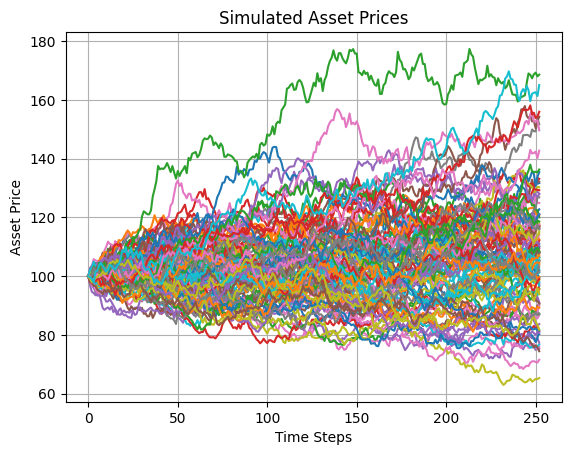

In [4]:
plt.plot(paths[:100].T)
plt.title("Simulated Asset Prices")
plt.xlabel("Time Steps")
plt.ylabel("Asset Price")
plt.grid(True)
plt.show()

**<h3>Valuation of European Call Option (Euler-Maruyama method)**

In [5]:
def european_call_option_price_EM(S0 ,K ,r ,sigma, T ,n_paths):

  paths = simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps = 252)

  payoff = np.maximum(paths[:,-1] - K, 0)

  price = np.exp(-r * T) * np.mean(payoff)

  se_eur_EM = np.std(payoff) / np.sqrt(n_paths)  # Standard Error of Payoffs

  return price, se_eur_EM



In [6]:
np.random.seed(42) # Seeding for consistency purposes
european_call_price_EM = european_call_option_price_EM(100, 100, 0.05, 0.2, 1, 50000)[0]
print("European Call Option Price:", round(european_call_price_EM, 4))

European Call Option Price: 10.4177


**<h3>Valuation of Binary Call Option (Euler-Maruyama method)**


In [7]:
def binary_call_option_price_EM(S0 ,K ,r ,sigma, T ,n_paths):

  paths = simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps = 252)

  payoff = (paths[:, -1] > K).astype(float) # Gives a boolean array as output and coverts to 1 or 0 (depending on True or False)

  price = np.exp(-r * T) * np.mean(payoff)

  se_bin_EM = np.std(payoff) / np.sqrt(n_paths)  # Standard Error of Payoffs

  return price, se_bin_EM

In [8]:
np.random.seed(42) # Seeding for consistency purposes
binary_call_price_EM = binary_call_option_price_EM(100, 100, 0.05, 0.2, 1, 50000)[0]
print("Binary Call Option Price:", round(binary_call_price_EM, 4))

Binary Call Option Price: 0.5323


**<h3>Variance Reduction Technique - Antithetic Variates (Euler-Maruyama method)**


Monte Carlo simulations can suffer from high variance. One of the common techniques to improve convergence is Antithetic Variates. This technique uses negatively correlated paths to reduce variance.

Note: Going forward, i will be using 25,000 paths (half of 50,000)
when doing any antithetic option valuation, this is as the +z and -z anyway
allows for 50,000 simulations.

In [9]:
def european_call_antithetic_EM(S0, K, r, sigma, T, n_paths, n_steps=252):
    dt = T / n_steps
    paths_1 = np.zeros((n_paths, n_steps + 1))
    paths_2 = np.zeros((n_paths, n_steps + 1))
    paths_1[:, 0] = S0
    paths_2[:, 0] = S0

    for t in range(1, n_steps + 1):
        z = np.random.standard_normal(n_paths)
        z_antithetic = -z

        paths_1[:, t] = paths_1[:, t-1] * (1 + r * dt + sigma * z * np.sqrt(dt))
        paths_2[:, t] = paths_2[:, t-1] * (1 + r * dt + sigma * z_antithetic * np.sqrt(dt))

        paths_1[:, t] = np.maximum(paths_1[:, t], 0) # this to avoid negative paths
        paths_2[:, t] = np.maximum(paths_2[:, t], 0) # this to avoid negative paths

    payoff = 0.5 * (np.maximum(paths_1[:, -1] - K, 0) +
                    np.maximum(paths_2[:, -1] - K, 0))

    price = np.exp(-r*T) * np.mean(payoff)

    se_eur_anti_EM = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

    return price, se_eur_anti_EM

In [10]:
np.random.seed(42) # Seeding for consistency purposes
antithetic_european_call_price_EM = european_call_antithetic_EM(100, 100, 0.05, 0.2, 1, 25000)[0]
print("European Call Price with Antithetic Variates:", round(antithetic_european_call_price_EM, 4))

European Call Price with Antithetic Variates: 10.4229


In [11]:
def binary_call_antithetic_EM(S0, K, r, sigma, T, n_paths, n_steps=252):
    dt = T / n_steps
    paths_1 = np.zeros((n_paths, n_steps + 1))
    paths_2 = np.zeros((n_paths, n_steps + 1))
    paths_1[:, 0] = S0
    paths_2[:, 0] = S0

    for t in range(1, n_steps + 1):
        z = np.random.standard_normal(n_paths)
        z_antithetic = -z

        paths_1[:, t] = paths_1[:, t-1] * (1 + r * dt + sigma * z * np.sqrt(dt))
        paths_2[:, t] = paths_2[:, t-1] * (1 + r * dt + sigma * z_antithetic * np.sqrt(dt))

        paths_1[:, t] = np.maximum(paths_1[:, t], 0) # this to avoid negative paths
        paths_2[:, t] = np.maximum(paths_2[:, t], 0) # this to avoid negative paths

    payoff = 0.5 * ((paths_1[:, -1] > K).astype(float) +
                    (paths_2[:, -1] > K).astype(float))

    price = np.exp(-r*T) * np.mean(payoff)

    se_bin_anti_EM = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

    return price,se_bin_anti_EM

In [12]:
np.random.seed(42) # Seeding for consistency purposes
antithetic_binary_call_price_EM = binary_call_antithetic_EM(100, 100, 0.05, 0.2, 1, 25000)[0]
print("Binary Call Price with Antithetic Variates:", round(antithetic_binary_call_price_EM, 4))

Binary Call Price with Antithetic Variates: 0.534


**<h2> B2) Valuations using Closed form solution**

<br>

Without dicretization, simulating the Stock price directly from t to T:

$$S_T = S_0 \exp\left(\left(r - \frac{1}{2}\sigma^2\right)T + \sigma\phi\sqrt{T}\right)$$

In [13]:
def simulate_gbm_paths_OneStep (S0, r, sigma, T, n_paths):
  dt = T
  paths = np.zeros((n_paths, 2))  # Creating a DataFrame with all zeros
  paths[:,0] = S0
  z = np.random.standard_normal(n_paths)
  ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)
  paths[:, 1] = ST

  return paths

In [14]:
paths_OneStep = pd.DataFrame(simulate_gbm_paths_OneStep(S0=100, r=0.05, sigma=0.2, T=1, n_paths=50000))
paths_OneStep

,0,1
0,100.0,126.199787
1,100.0,79.344726
2,100.0,81.219059
3,100.0,62.108813
4,100.0,125.806221
...,...,...
49995,100.0,109.191342
49996,100.0,93.860725
49997,100.0,102.106010
49998,100.0,103.482972


**<h3>Valuation of European Call Option (Closed form solution)**

In [15]:
def european_call_option_price_CFS(S0 ,K ,r ,sigma, T ,n_paths):

  paths = simulate_gbm_paths_OneStep(S0, r, sigma, T, n_paths)

  payoff = np.maximum(paths[:,-1] - K, 0)

  price = np.exp(-r * T) * np.mean(payoff)

  se_eur_CFS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

  return price, se_eur_CFS

In [16]:
np.random.seed(42) # Seeding for consistency purposes
european_call_price_CFS = european_call_option_price_CFS(100, 100, 0.05, 0.2, 1, 50000)[0]
print("European Call Option Price:", round(european_call_price_CFS, 4))

European Call Option Price: 10.4462


**<h3>Valuation of Binary Call Option (Closed form solution)**

In [17]:
def binary_call_option_price_CFS(S0 ,K ,r ,sigma, T ,n_paths):

  paths = simulate_gbm_paths_OneStep(S0, r, sigma, T, n_paths)

  payoff = (paths[:, -1] > K).astype(float) # Gives a boolean array as output and coverts to 1 or 0 (depending on True or False)

  price = np.exp(-r * T) * np.mean(payoff)

  se_bin_CFS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

  return price, se_bin_CFS

In [18]:
np.random.seed(42) # Seeding for consistency purposes
binary_call_price_CFS = binary_call_option_price_CFS(100, 100, 0.05, 0.2, 1, 50000)[0]
print("Binary Call Option Price:", round(binary_call_price_CFS, 4))

Binary Call Option Price: 0.5329


**<h3>Variance Reduction Technique - Antithetic Variates (Closed form solution)**


Note: This antithetic implementation is the simplest one amongst the three schemes, as it is single step, with no use of loop, and a simple paring of z  with -z.


In [19]:
def european_call_antithetic_CFS(S0, K, r, sigma, T, n_paths):
    z = np.random.standard_normal(n_paths)
    z_antithetic = -z                              # antithetic pair

    ST_1 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    ST_2 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z_antithetic)

    payoff = 0.5 * (np.maximum(ST_1 - K, 0) +
                    np.maximum(ST_2 - K, 0))

    price = np.exp(-r*T) * np.mean(payoff)

    se_eur_anti_CFS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

    return price, se_eur_anti_CFS

In [20]:
np.random.seed(42) # Seeding for consistency purposes
antithetic_european_call_price_CFS = european_call_antithetic_CFS(100, 100, 0.05, 0.2, 1, 25000)[0]
print("European Call Price with Antithetic Variates:", round(antithetic_european_call_price_CFS, 4))

European Call Price with Antithetic Variates: 10.4306


In [21]:
def binary_call_antithetic_CFS(S0, K, r, sigma, T, n_paths):
    z = np.random.standard_normal(n_paths)
    z_antithetic = -z

    ST_1 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    ST_2 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z_antithetic)
    payoff = 0.5 * ((ST_1 > K).astype(float) +
                    (ST_2 > K).astype(float))

    price = np.exp(-r*T) * np.mean(payoff)

    se_bin_anti_CFS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

    return price, se_bin_anti_CFS

In [22]:
np.random.seed(42) # Seeding for consistency purposes
antithetic_binary_call_price_CFS = binary_call_antithetic_CFS(100, 100, 0.05, 0.2, 1, 25000)[0]
print("Binary Call Price with Antithetic Variates:", round(antithetic_binary_call_price_CFS, 4))

Binary Call Price with Antithetic Variates: 0.533


**<h2> B3) Valuations using Milstein Scheme**

<br>

Below is the Milstein Correction Term, this term comes from applying the Ito's lemma to the diffusion term: $$\frac{1}{2}\sigma^2\left(\phi^2 - 1\right)\delta t$$


<br>

Geometric Brownian Motion Paths after introducing this correction term to the Euler-Maruyama discretization is:

$$S_{i+1} = S_i \left(1 + r\,\delta t + \sigma\,\phi\sqrt{\delta t} + \frac{1}{2}\sigma^2\left(\phi^2 - 1\right)\delta t\right)$$

<br>

Basically, Milstein reduces discretization error due to the higher order term.

In [23]:
def simulate_gbm_paths_MLS (S0, r, sigma, T, n_paths, n_steps):
  dt = T/n_steps
  paths = np.zeros((n_paths, n_steps + 1))  # Creating a DataFrame with all zeros
  paths[:,0] = S0

  for t in range (1,n_steps + 1):
    z = np.random.standard_normal(n_paths)

    # Adding Milstein Correction term to Euler Maruyama discretization

    paths[:,t] = paths[:,t-1] * (1 + r * dt + sigma * z * np.sqrt(dt) + 0.5 * sigma**2 * (z**2 - 1) * dt)

    paths[:, t] = np.maximum(paths[:, t], 0) # this to avoid negative paths

  return paths

In [24]:
paths_MLS = pd.DataFrame(simulate_gbm_paths_MLS(S0=100, r=0.05, sigma=0.2, T=1, n_paths=50000, n_steps=252))
paths_MLS

,0,1,2,3,4,5,6,7,8,9,...,243,244,245,246,247,248,249,250,251,252
0,100.0,100.227417,99.136237,99.845036,100.596611,100.649708,101.465163,102.582683,100.858491,101.765427,...,111.111954,109.745886,108.609469,107.643667,109.500138,110.326826,112.301694,114.675085,112.635691,114.160931
1,100.0,100.027346,100.822225,100.620885,101.383455,100.406548,99.211163,100.264783,98.535176,97.415149,...,111.192221,114.594589,114.315279,118.116518,116.740342,118.328420,114.791177,114.616263,113.905118,115.086509
2,100.0,99.470176,98.077383,97.422890,97.869795,96.410441,97.539529,96.190290,96.143243,95.514555,...,82.350918,80.636202,78.190693,78.016371,77.987148,77.070346,77.064437,77.016457,76.410175,77.498146
3,100.0,100.008722,101.489639,102.855609,104.677809,105.614238,106.028748,107.930495,107.534250,109.118713,...,119.827593,118.191632,118.503426,118.700169,119.897182,120.004060,116.749476,117.942899,117.162130,116.171515
4,100.0,100.632219,99.700553,100.964914,102.280135,102.782677,103.540918,104.128155,103.375600,104.457952,...,129.849712,129.139679,128.562357,129.060473,129.424683,128.049159,128.013647,127.161743,129.779928,129.053731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,100.0,99.681129,98.582692,97.057962,96.266656,95.471958,96.517721,95.918397,97.301155,97.025609,...,75.334802,74.927395,76.164794,77.022384,78.354917,78.002968,76.108289,77.288198,78.143990,78.572607
49996,100.0,101.824682,103.522593,103.421058,104.129636,104.145889,104.102547,105.481678,104.843291,104.981575,...,134.642858,133.652918,130.843807,130.380357,131.461998,130.900258,129.910703,131.122746,129.879498,129.790294
49997,100.0,100.283682,99.194339,100.184821,99.307275,97.762962,98.418340,96.962231,98.460900,99.510613,...,123.052190,121.024892,122.928018,123.283459,121.178021,120.927400,123.268273,124.260040,124.402330,123.016511
49998,100.0,101.290637,101.832654,102.265848,104.345514,103.738696,104.000595,103.577757,102.011675,101.597644,...,96.479908,95.881161,97.731671,95.125540,93.639766,93.873018,92.856432,93.733443,92.240702,92.976385


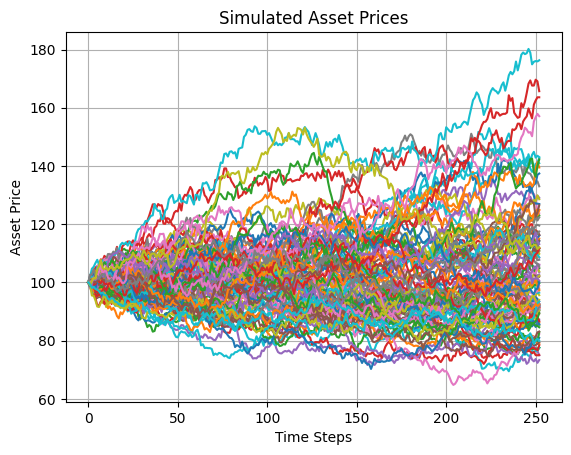

In [25]:
plt.plot(paths_MLS[:100].T)
plt.title("Simulated Asset Prices")
plt.xlabel("Time Steps")
plt.ylabel("Asset Price")
plt.grid(True)
plt.show()

**<h3>Valuation of European Call Option (Milstein Scheme)**

In [26]:
def european_call_option_price_MLS(S0 ,K ,r ,sigma, T ,n_paths):

  paths = simulate_gbm_paths_MLS(S0, r, sigma, T, n_paths, n_steps = 252)

  payoff = np.maximum(paths[:,-1] - K, 0)

  price = np.exp(-r * T) * np.mean(payoff)

  se_eur_MLS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

  return price, se_eur_MLS

In [27]:
np.random.seed(42) # Seeding for consistency purposes
european_call_price_MLS = european_call_option_price_MLS(100, 100, 0.05, 0.2, 1, 50000)[0]
print("European Call Option Price:", round(european_call_price_MLS, 4))

European Call Option Price: 10.4161


**<h3>Valuation of Binary Call Option (Milstein Scheme)**

In [28]:
def binary_call_option_price_MLS(S0 ,K ,r ,sigma, T ,n_paths):

  paths = simulate_gbm_paths_MLS(S0, r, sigma, T, n_paths, n_steps = 252)

  payoff = (paths[:, -1] > K).astype(float) # Gives a boolean array as output and coverts to 1 or 0 (depending on True or False)

  price = np.exp(-r * T) * np.mean(payoff)

  se_bin_MLS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

  return price,se_bin_MLS

In [29]:
np.random.seed(42) # Seeding for consistency purposes
binary_call_price_MLS = binary_call_option_price_MLS(100, 100, 0.05, 0.2, 1, 50000)[0]
print("Binary Call Option Price:", round(binary_call_price_MLS, 4))

Binary Call Option Price: 0.5321


**<h3>Variance Reduction Technique - Antithetic Variates (Milstein Scheme)**

Note: Interesting point to note here is as z_antithetic = -z, therefore z_antithetic^2 = z^2 and thus the Milstein correction term would be same for both the paths


In [30]:
def european_call_antithetic_MLS(S0, K, r, sigma, T, n_paths, n_steps=252):
    dt = T / n_steps
    paths_1 = np.zeros((n_paths, n_steps + 1))
    paths_2 = np.zeros((n_paths, n_steps + 1))
    paths_1[:, 0] = S0
    paths_2[:, 0] = S0

    for t in range(1, n_steps + 1):
        z = np.random.standard_normal(n_paths)
        z_antithetic = -z

        paths_1[:, t] = paths_1[:, t-1] * (1 + r * dt + sigma * z * np.sqrt(dt)
                         + 0.5 * sigma**2 * (z**2 - 1) * dt)
        paths_2[:, t] = paths_2[:, t-1] * (1 + r * dt + sigma * z_antithetic * np.sqrt(dt)
                         + 0.5 * sigma**2 * (z_antithetic**2 - 1) * dt)

        paths_1[:, t] = np.maximum(paths_1[:, t], 0) # this to avoid negative paths
        paths_2[:, t] = np.maximum(paths_2[:, t], 0) # this to avoid negative paths

    payoff = 0.5 * (np.maximum(paths_1[:, -1] - K, 0) +
                    np.maximum(paths_2[:, -1] - K, 0))

    price = np.exp(-r*T) * np.mean(payoff)

    se_eur_anti_MLS = np.std(payoff) / np.sqrt(n_paths) # Standard Error

    return price, se_eur_anti_MLS

In [31]:
np.random.seed(42) # Seeding for consistency purposes
antithetic_european_call_price_MLS = european_call_antithetic_MLS(100, 100, 0.05, 0.2, 1, 25000)[0]
print("European Call Price with Antithetic Variates:", round(antithetic_european_call_price_MLS, 4))

European Call Price with Antithetic Variates: 10.4219


In [32]:
def binary_call_antithetic_MLS(S0, K, r, sigma, T, n_paths, n_steps=252):
    dt = T / n_steps
    paths_1 = np.zeros((n_paths, n_steps + 1))
    paths_2 = np.zeros((n_paths, n_steps + 1))
    paths_1[:, 0] = S0
    paths_2[:, 0] = S0

    for t in range(1, n_steps + 1):
        z = np.random.standard_normal(n_paths)
        z_antithetic = -z

        paths_1[:, t] = paths_1[:, t-1] * (1 + r * dt + sigma * z * np.sqrt(dt)
                         + 0.5 * sigma**2 * (z**2 - 1) * dt)
        paths_2[:, t] = paths_2[:, t-1] * (1 + r * dt + sigma * z_antithetic * np.sqrt(dt)
                         + 0.5 * sigma**2 * (z_antithetic**2 - 1) * dt)

        paths_1[:, t] = np.maximum(paths_1[:, t], 0) # this to avoid negative paths
        paths_2[:, t] = np.maximum(paths_2[:, t], 0) # this to avoid negative paths

    payoff = 0.5 * ((paths_1[:, -1] > K).astype(float) +
                    (paths_2[:, -1] > K).astype(float))

    price = np.exp(-r*T) * np.mean(payoff)

    se_bin_anti_MLS = np.std(payoff) / np.sqrt(n_paths) # Standard Error of Payoffs

    return price, se_bin_anti_MLS

In [33]:
np.random.seed(42) # Seeding for consistency purposes
antithetic_binary_call_price_MLS = binary_call_antithetic_MLS(100, 100, 0.05, 0.2, 1, 25000)[0]
print("Binary Call Price with Antithetic Variates:", round(antithetic_binary_call_price_MLS, 4))

Binary Call Price with Antithetic Variates: 0.5336


**<h1> C) BSM Option Valuation (will act as a benchmark)**

**Black-Scholes Formula**

The Black-Scholes equation describes the price of the option over time and the same is as follows:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

Solving the above equation, the value of a **European Call Option** for a non-dividend paying stock comes as:

$$C = SN(d_1) - Ke^{-rt}N(d_2)$$

The value of a **Binary Call Option** is:

$$C_{binary} = e^{-rt} N(d_2)$$

where,

$$d_1 = \frac{1}{\sigma\sqrt{t}}\left[\ln\left(\frac{S}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)t\right]$$

$$d_2 = d_1 - \sigma\sqrt{t}$$

In [34]:
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

In [35]:
european_call_price_BSM = black_scholes_call(100, 100, 0.05, 0.2, 1)
print("European Call Option Price:", round(european_call_price_BSM, 4))

European Call Option Price: 10.4506


In [36]:
def black_scholes_binary(S0, K, r, sigma, T):
    d2 = (np.log(S0/K) + (r - 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return np.exp(-r*T) * norm.cdf(d2)

In [37]:
binary_call_price_BSM = black_scholes_binary(100, 100, 0.05, 0.2, 1)
print("Binary Call Option Price:", round(binary_call_price_BSM, 4))

Binary Call Option Price: 0.5323


**<h1>D) Results, Comparison, Error TableS for Option values under different schemes/ methods**

**<h2> D1) Comparison of Option values under different schemes/ methods**

In [38]:
results = {
    'Method': ['Euler-Maruyama', 'Closed Form', 'Milstein', 'Black-Scholes'],
    'European Call Price': [european_call_price_EM, european_call_price_CFS,
                            european_call_price_MLS,  european_call_price_BSM],
    'European Call Price with AV': [antithetic_european_call_price_EM, antithetic_european_call_price_CFS,
                                    antithetic_european_call_price_MLS, european_call_price_BSM],
    'Binary Call Price':   [binary_call_price_EM,  binary_call_price_CFS,
                            binary_call_price_MLS, binary_call_price_BSM],
    'Binary Call Price with AV':   [antithetic_binary_call_price_EM, antithetic_binary_call_price_CFS,
                                    antithetic_binary_call_price_MLS, binary_call_price_BSM]
}

df_table = pd.DataFrame(results)
df_table = df_table.set_index('Method')
df_table = df_table.round(4)
df_table

# AV stands for Antithetic Variates.

,European Call Price,European Call Price with AV,Binary Call Price,Binary Call Price with AV
Method,,,,
Euler-Maruyama,10.4177,10.4229,0.5323,0.5340
Closed Form,10.4462,10.4306,0.5329,0.5330
Milstein,10.4161,10.4219,0.5321,0.5336
Black-Scholes,10.4506,10.4506,0.5323,0.5323


Basis the table above we can see that the Monte Carlo Schemes produce price close to BSM benchmark (European Call = 10.4506 & Binary Call = 0.5323. The Closed Form solution is the most accurate as it has no dicretization error.

<br> <br>

**<h2> D2) Absolute Errors for the Monte Carlo Schmes with respect to BSM prices**

In [39]:
Abs_Error = {
    'Method': ['Euler-Maruyama', 'Closed Form', 'Milstein'],
    'AE European Call Price': [abs(european_call_price_EM-european_call_price_BSM),
                            abs(european_call_price_CFS-european_call_price_BSM),
                            abs(european_call_price_MLS-european_call_price_BSM)],
    'AE European Call Price with AV': [abs(antithetic_european_call_price_EM-european_call_price_BSM),
                                    abs(antithetic_european_call_price_CFS-european_call_price_BSM),
                                    abs(antithetic_european_call_price_MLS-european_call_price_BSM)],
    'AE Binary Call Price':   [abs(binary_call_price_EM-binary_call_price_BSM),
                            abs(binary_call_price_CFS-binary_call_price_BSM),
                            abs(binary_call_price_MLS-binary_call_price_BSM)],
    'AE Binary Call Price with AV':   [abs(antithetic_binary_call_price_EM-binary_call_price_BSM),
                                    abs(antithetic_binary_call_price_CFS-binary_call_price_BSM),
                                    abs(antithetic_binary_call_price_MLS-binary_call_price_BSM)]
}

df_Abs_Error = pd.DataFrame(Abs_Error)
df_Abs_Error = df_Abs_Error.set_index('Method')
df_Abs_Error = df_Abs_Error.round(4)
df_Abs_Error

# AV stands for Antithetic Variates.

,AE European Call Price,AE European Call Price with AV,AE Binary Call Price,AE Binary Call Price with AV
Method,,,,
Euler-Maruyama,0.0329,0.0276,0.0001,0.0016
Closed Form,0.0044,0.0200,0.0005,0.0007
Milstein,0.0345,0.0287,0.0002,0.0013


The Closed Form Solution has the smallest absolute error with respect to the BSM for both the type of options, this is because the Closed Form simulates the GBM in exactly one step.

<br> <br>

**<h2> D3) Standard Error of Payoffs under different schemes/ methods**


$$\text{Error} = \frac{\sigma}{\sqrt{n}} \sim O\left(\frac{1}{\sqrt{n}}\right)$$

where:
- $\sigma$ — standard deviation of the payoffs
- $n$ — number of simulations/paths
- $O(1/\sqrt{n})$ — order of convergence (Central Limit Theorem)

<br>

**Standard Error calculations are already part of option valuation functions defined above**

In [40]:
np.random.seed(42)
SE_EUR_EM = european_call_option_price_EM(100, 100, 0.05, 0.2, 1, 50000)[1]
np.random.seed(42)
SE_BIN_EM = binary_call_option_price_EM(100, 100, 0.05, 0.2, 1, 50000)[1]
np.random.seed(42)
SE_EUR_CFS = european_call_option_price_CFS(100, 100, 0.05, 0.2, 1, 50000)[1]
np.random.seed(42)
SE_BIN_CFS = binary_call_option_price_CFS(100, 100, 0.05, 0.2, 1, 50000)[1]
np.random.seed(42)
SE_EUR_MLS = european_call_option_price_MLS(100, 100, 0.05, 0.2, 1, 50000)[1]
np.random.seed(42)
SE_BIN_MLS = binary_call_option_price_MLS(100, 100, 0.05, 0.2, 1, 50000)[1]
np.random.seed(42)
SE_EUR_EM_ANTI = european_call_antithetic_EM (100, 100, 0.05, 0.2, 1, 25000)[1]
np.random.seed(42)
SE_BIN_EM_ANTI = binary_call_antithetic_EM (100, 100, 0.05, 0.2, 1, 25000)[1]
np.random.seed(42)
SE_EUR_CFS_ANTI = european_call_antithetic_CFS (100, 100, 0.05, 0.2, 1, 25000)[1]
np.random.seed(42)
SE_BIN_CFS_ANTI = binary_call_antithetic_CFS (100, 100, 0.05, 0.2, 1, 25000)[1]
np.random.seed(42)
SE_EUR_MLS_ANTI = european_call_antithetic_MLS (100, 100, 0.05, 0.2, 1, 25000)[1]
np.random.seed(42)
SE_BIN_MLS_ANTI = binary_call_antithetic_MLS (100, 100, 0.05, 0.2, 1, 25000)[1]

In [41]:
#Tabulating the Standard Errors

Std_Error = {
    'Method': ['Euler-Maruyama', 'Closed Form', 'Milstein'],
    'SE European Call Price': [SE_EUR_EM, SE_EUR_CFS, SE_EUR_MLS],
    'SE European Call Price with AV': [SE_EUR_EM_ANTI, SE_EUR_CFS_ANTI, SE_EUR_MLS_ANTI],
    'SE Binary Call Price': [SE_BIN_EM,SE_BIN_CFS,SE_BIN_MLS],
    'SE Binary Call Price with AV':   [SE_BIN_EM_ANTI,SE_BIN_CFS_ANTI,SE_BIN_MLS_ANTI]
}

df_Std_Error = pd.DataFrame(Std_Error)
df_Std_Error = df_Std_Error.set_index('Method')
df_Std_Error = df_Std_Error.round(4)
df_Std_Error

,SE European Call Price,SE European Call Price with AV,SE Binary Call Price,SE Binary Call Price with AV
Method,,,,
Euler-Maruyama,0.0689,0.0486,0.0022,0.001
Closed Form,0.0690,0.0489,0.0022,0.001
Milstein,0.0689,0.0486,0.0022,0.001


There is major reduction in Standard Error when using Antithetic Variates to value options.

<br><br>

**<h2> E) Observations**

1) From the comparison table above (Point D1), all three Monte Carlo schemes produce pricess close to the Black-Scholes price (European Call = 10.4506, Binary Call = 0.5323 )

2) From the comparison in the Standard Error table above (Point D3), anthetic varieties have reduces standard error (reduced variance) when compared to all the plain Monte Carlo schemes. This confirms antithetic variance reduction technique help reduce the variance/ standard error.

3) Binary call option has a lower standard error than the european call under all the monte carlo schemes, this since the binary options payoff is either 0 or 1, while the payoff for european options is unbounded.

4) The European call option value is significantly higher than the Binary call option price across all the methods/ scheme, this is because when in the money, an european call pays the full upside over and above the strike while a binary pays only 1.

5) One issue with the discretization schemes like Euler-Maruyama and Milstein scheme is that these can produce negative assest prices in case of extreme movements, this voilates the GBM. Whereas the Closed Form solution guarantees non-negative asset asset prices due to the use of exponential function.

6) The Closed Form solution is theretically the most accurate scheme as it eliminates discretization entirely, only the below sampling error remains $$O\left(\frac{1}{\sqrt{n}}\right)$$

7) Because of the above sampling error, four times as many paths are needed to half the error. This slow convergence is the computational limitation of Monte Carlo method.

**<h2> F) Conclusion**

1) This notebook implemented and compared three Monte Carlo schemes --> Euler Maruyama, Closed Form and Milstein scheme to value European Call Option and the Binary Call Option under the risk-neutral GBM framework.

2) All the three schemes produce results that converge to the Black and Scholes price, Closed Form being the most accurate and Milstein scheme helping Euler Maruyama to reduce error by introducing the correction term.

3) The antithetic varieties help reduce the standard error across all the schemes and hep achieve same level of accuracy with half the number of paths/ randomness.

4) The European call option value is significantly higher than the Binary call option price across all the methods/ scheme, this is because when in the money, an european call pays the full upside over and above the strike while a binary pays only 1.

5) This slow convergence is the computational limitation of Monte Carlo method.

**<h2> G) References**


Fitch Learning - CQF Program Notes & Python Labs

1) Notes - **Intro to Numerical Methods** (Dr Riaz Ahmed)
2) Notes - **Further Numerical Methods** in Monte Carlo & FDM (Dr Riaz Ahmed)
3) Python Labs - **Monte Carlo Simulation** (Mr Kannan Singaravelu)
4) Exam 2 Reference Note - **Resource on Milstein** (Dr Riaz Ahmed)
